# 06 — Combining Grids

This notebook demonstrates how to merge multiple stellar atmosphere grids into a unified ensemble.

**Key method:** `SED.combine()`

Individual libraries often cover only part of stellar parameter space. Combining them lets MESA draw on the best available model at each point.

In [1]:
from sed_tools.api import SED
import matplotlib.pyplot as plt
import numpy as np


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib64/python3.13/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib64/python3.13/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/usr/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 739, 

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Why Combine Grids?

Common use cases:
- Extending temperature coverage (e.g. hot O-star models + cool M-dwarf models)
- Filling parameter-space gaps between libraries
- Creating a single comprehensive grid for population synthesis

Under the hood, `SED.combine()` calls `combine_stellar_atm.py`, which aligns all grids onto a common wavelength axis via `_resample.py` (log-linear interpolation within coverage, zero-fill outside), then writes a new binary flux cube.

## 2. Inspecting Individual Grids Before Combining

It is good practice to check what each grid actually covers before merging.

In [2]:
local_catalogs = SED.query(include_remote=False)

print(f"{'Model':30s} {'Teff min':>10s} {'Teff max':>10s} {'logg min':>10s} {'logg max':>10s}")
print("-" * 75)
for c in local_catalogs:
    if c.teff_range:
        print(f"{c.name:30s} {c.teff_range[0]:>10.0f} {c.teff_range[1]:>10.0f} "
              f"{c.logg_range[0]:>10.2f} {c.logg_range[1]:>10.2f}")

Model                            Teff min   Teff max   logg min   logg max
---------------------------------------------------------------------------
Husfeld                             35000      80000       4.00       7.00
Kurucz                               3500      50000       0.00       5.00
Kurucz2003                           3500      50000       0.00       5.00
Kurucz2003all                        4000       8000       3.00       5.00
Kurucz2003all__alpha_0.4__lh_1.25__vtur_2       3500      50000       0.00       5.00
Kurucz2003all__alpha_00              3500      50000       0.00       5.00
Kurucz2003all__alpha_04              3500      50000       0.00       5.00
Kurucz2003all__alpha_0__lh_1.25__vtur_2       3500      50000       0.00       5.00
Kurucz2003alp                        3500      50000       0.00       5.00
NextGen2                              900      10000       3.00       6.00
bbody                                  10     200000     999.90     999.90
hres

## 3. Creating a Combined Grid

`SED.combine()` takes a list of installed model names and an output name. The result is written to disk and returned as an `SED` instance ready for interpolation.


Combining 3 models:
  - Kurucz2003all
  - NextGen2
  - hres

Loading model data...
  Loading Kurucz2003all...
  Loading NextGen2...
  Loading hres...

Creating unified parameter grids...

Analyzing wavelength coverage...
  Range: 3000 - 24999 Å
  Points: 440, Resolution: 50.0 Å

Building combined flux cube...

Building flux cube: (113, 20, 15, 440)
Memory: 113.8 MB
Reference model: Kurucz2003all
  Normalizing to: Kurucz2003all
  Normalizing to: Kurucz2003all

Processing Kurucz2003all...


Model 1: 100%|██████████████████████████████████████████████████████████████████████████████████| 850/850 [00:00<00:00, 3126.71it/s]



Processing NextGen2...


Model 2: 100%|█████████████████████████████████████████████████████████████████████████████████| 2712/2712 [00:10<00:00, 266.13it/s]



Processing hres...


Model 3: 100%|█████████████████████████████████████████████████████████████████████████████████| 1650/1650 [00:03<00:00, 460.47it/s]



Filling 29271 empty grid points...

Saved flux cube: /home/njm/SED_Tools/data/stellar_models/my_combined_grid/flux_cube.bin

Copying SED files...


Copying: 100%|████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.12it/s]


Saved lookup table: /home/njm/SED_Tools/data/stellar_models/my_combined_grid/lookup_table.csv
Total models: 5212

Creating visualization...
Saved: /home/njm/SED_Tools/data/stellar_models/my_combined_grid/parameter_space.png

SUMMARY
Grid: 113 × 20 × 15 = 33,900 points
Teff: 900 - 55000 K
logg: -0.50 - 6.00
[M/H]: -10.00 - 3.00

Contributions:
  Kurucz2003all: 2,408 (7.1%)
  NextGen2: 11,326 (33.4%)
  hres: 20,166 (59.5%)
Saved: /home/njm/SED_Tools/data/stellar_models/my_combined_grid/sed_samples.png

Successfully combined 3 models!
Output: /home/njm/SED_Tools/data/stellar_models/my_combined_grid
Combined catalog written: my_combined_grid


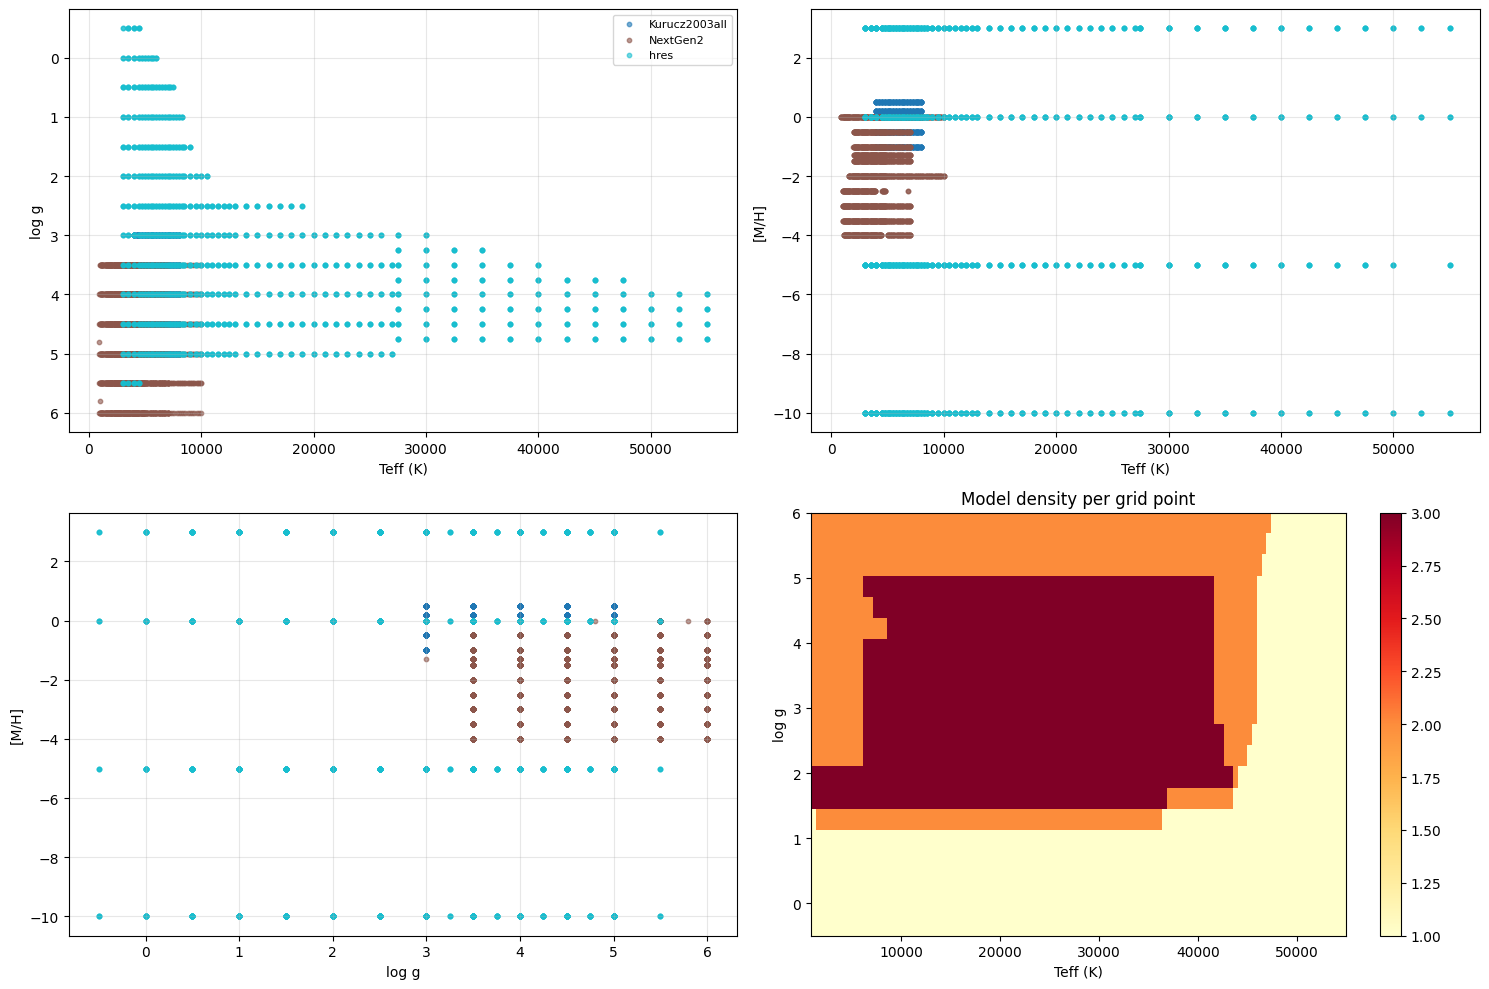

In [5]:
# List the models you want to combine (must be installed locally)
models_to_combine = ['Kurucz2003all', 'NextGen2', 'hres']

ensemble = SED.combine(
    catalogs=models_to_combine,
    output='my_combined_grid',
)
print(f"Combined catalog written: {ensemble.cat.name}")

## 4. Using the Combined Grid

The ensemble behaves identically to any other `SED` instance — you can interpolate at any parameters within the union of the input grids.

In [6]:
if 'ensemble' in locals():
    ranges = ensemble.parameter_ranges()
    print("Combined parameter ranges:")
    for param, (lo, hi) in ranges.items():
        print(f"  {param:12s}: {lo} → {hi}")

    print(f"\nTotal spectra: {len(ensemble.cat)}")
    # Interpolate a spectrum
    spec = ensemble(teff=5777, logg=4.44, metallicity=0.0)
    print(f"Interpolated: {len(spec.wl)} wavelength points")

Combined parameter ranges:
  teff        : 900.0 → 55000.0
  logg        : -0.5 → 6.0
  metallicity : -10.0 → 3.0

Total spectra: 5212
Interpolated: 440 wavelength points


## 5. Loading an Existing Combined Grid

If you have already built a combined grid, load it with `SED.local()` just like any other catalog.

In [7]:
ensemble = SED.local('my_combined_grid')

## 6. Plotting Parameter Space Coverage

A simple visualisation of the Teff–logg coverage of each installed model.

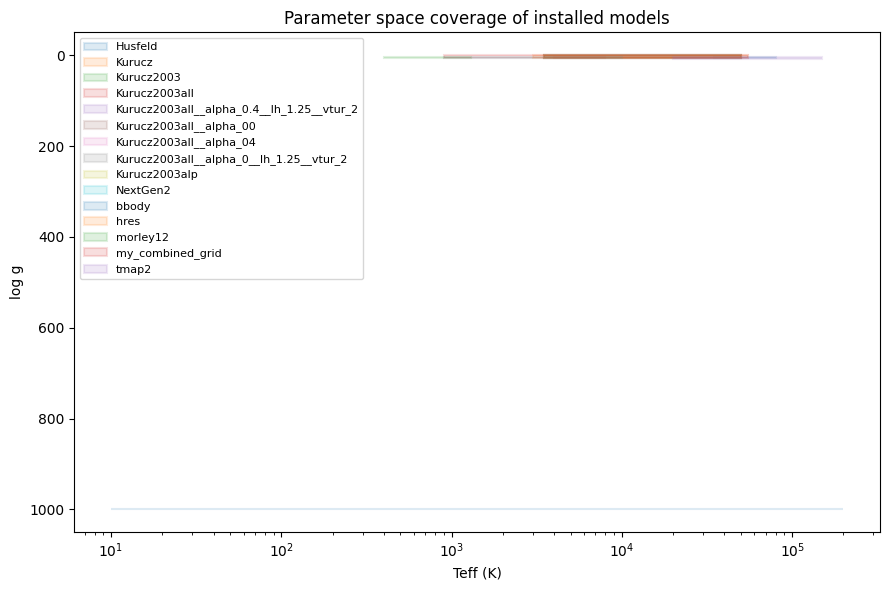

In [9]:
local_catalogs = SED.query(include_remote=False)
catalogs_with_ranges = [c for c in local_catalogs if c.teff_range and c.logg_range]

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('tab10')

for i, c in enumerate(catalogs_with_ranges):
    x0, x1 = c.teff_range
    y0, y1 = c.logg_range
    rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                          linewidth=1.5, edgecolor=cmap(i % 10),
                          facecolor=cmap(i % 10), alpha=0.15, label=c.name)
    ax.add_patch(rect)

ax.set_xscale('log')
ax.set_xlabel('Teff (K)')
ax.set_ylabel('log g')
ax.set_title('Parameter space coverage of installed models')
ax.invert_yaxis()
ax.legend(fontsize=8, loc='best')
ax.autoscale()
plt.tight_layout()
plt.show()